In [14]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import *
from imblearn.over_sampling import SMOTE
import warnings; warnings.filterwarnings('ignore')

In [15]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
print("Shape:", df.shape)
display(df.head())

Shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [16]:
print("Dataset Info:")
df.info()
print("\nMissing Values:\n", df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB

Mis

Target Distribution:
 DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


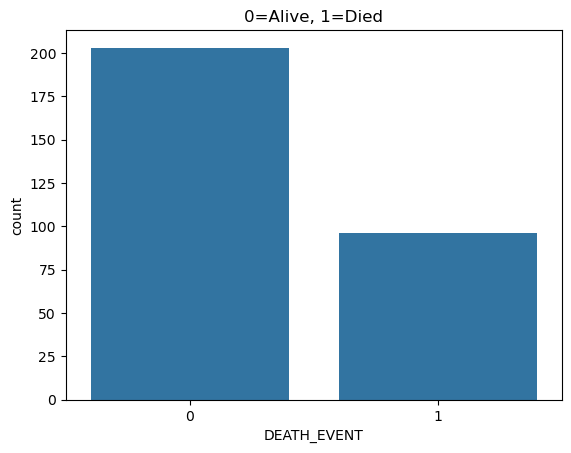

In [17]:
print("Target Distribution:\n", df['DEATH_EVENT'].value_counts())
sns.countplot(x='DEATH_EVENT', data=df)
plt.title("0=Alive, 1=Died"); plt.show()

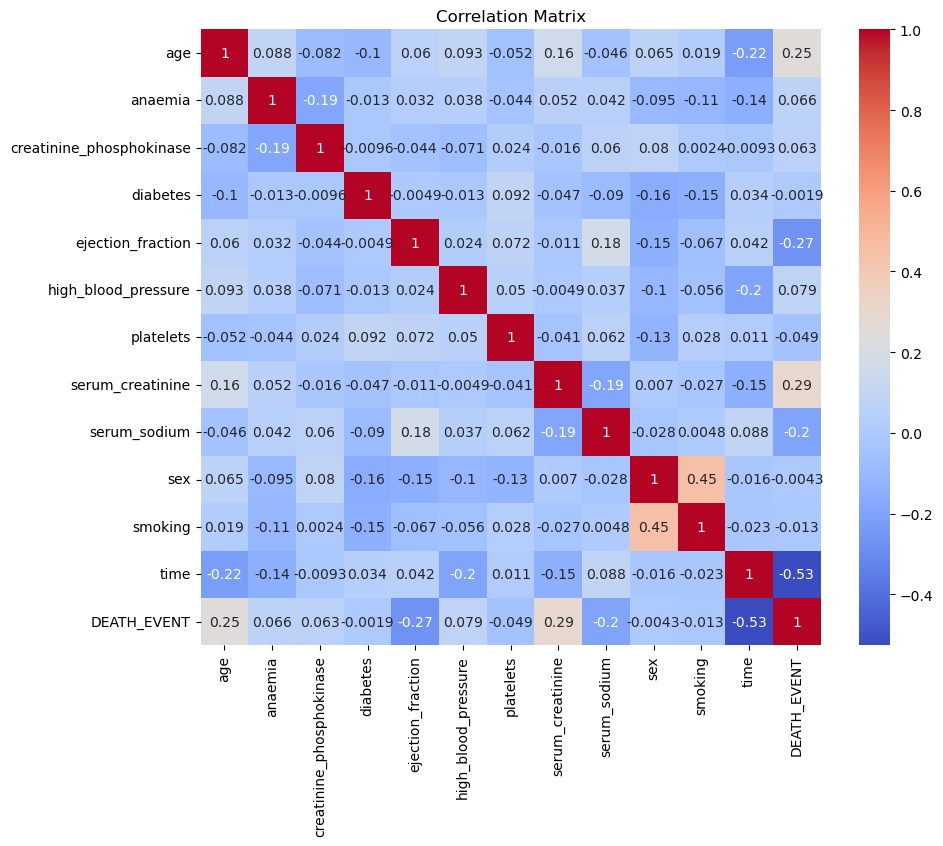

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix"); plt.show()

In [19]:
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']
X = StandardScaler().fit_transform(X)
print("Scaling Done")

Scaling Done


In [20]:
print("Before SMOTE:", pd.Series(y).value_counts())
X, y = SMOTE(random_state=42).fit_resample(X, y)
print("After SMOTE:", pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Before SMOTE: DEATH_EVENT
0    203
1     96
Name: count, dtype: int64
After SMOTE: DEATH_EVENT
1    203
0    203
Name: count, dtype: int64


In [21]:
models = {"LR": LogisticRegression(max_iter=500),
          "RF": RandomForestClassifier(),
          "SVM": SVC()}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    results[name] = [acc, f1]
    print(f"{name} -> Acc: {round(acc,4)} | F1: {round(f1,4)}")
    print(classification_report(y_test,y_pred))

LR -> Acc: 0.8049 | F1: 0.7949
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        41
           1       0.84      0.76      0.79        41

    accuracy                           0.80        82
   macro avg       0.81      0.80      0.80        82
weighted avg       0.81      0.80      0.80        82

RF -> Acc: 0.8659 | F1: 0.8706
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        41
           1       0.84      0.90      0.87        41

    accuracy                           0.87        82
   macro avg       0.87      0.87      0.87        82
weighted avg       0.87      0.87      0.87        82

SVM -> Acc: 0.8415 | F1: 0.8434
              precision    recall  f1-score   support

           0       0.85      0.83      0.84        41
           1       0.83      0.85      0.84        41

    accuracy                           0.84        82
   macro avg       0.84      0.84 

In [22]:
results_df = pd.DataFrame(results, index=['Acc','F1']).T
display(results_df)
best = results_df['Acc'].idxmax()
print("\nBest Model:", best)

print(f"\nTuning {best}...")
grid = GridSearchCV(RandomForestClassifier(), {'n_estimators':[100,200]}, cv=5).fit(X_train,y_train)
print("Best Params:", grid.best_params_)
print("Best Accuracy after Tuning:", round(grid.best_score_,4))

,Acc,F1
LR,0.804878,0.794872
RF,0.865854,0.870588
SVM,0.841463,0.843373



Best Model: RF

Tuning RF...
Best Params: {'n_estimators': 100}
Best Accuracy after Tuning: 0.8799
